**Тема:** Идентификация потенциальных сбоев в работе ветряных турбин по данным вибрации и температуры

Датасет: https://huggingface.co/datasets/vossmoos/vestasv52-scada-windturbine-granada

In [1]:
!pip install datasets >> None

In [2]:
try:
    import shap
except:
    !pip install shap
finally:
    import shap

In [3]:
from datasets import load_dataset

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
import matplotlib.pyplot as plt

# Загрузка и описание датасета

In [4]:
dataset = load_dataset('vossmoos/vestasv52-scada-windturbine-granada')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

(…)rbox_bearing_wear_elevated_temp_data.csv: 0.00B [00:00, ?B/s]

(…)_increased_yaw_error_20250919_153935.csv: 0.00B [00:00, ?B/s]

(…)igh_wind_power_regulation_simulation.csv: 0.00B [00:00, ?B/s]

normal_operation_moderate_wind_data.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/40000 [00:00<?, ? examples/s]

In [5]:
dataset['train'].features

{'Timestamp': Value('string'),
 'WindSpeed': Value('float64'),
 'StdDevWindSpeed': Value('float64'),
 'WindDirAbs': Value('float64'),
 'WindDirRel': Value('float64'),
 'Power': Value('float64'),
 'MaxPower': Value('float64'),
 'MinPower': Value('float64'),
 'StdDevPower': Value('float64'),
 'AvgRPow': Value('float64'),
 'Pitch': Value('float64'),
 'GenRPM': Value('float64'),
 'RotorRPM': Value('float64'),
 'EnvirTemp': Value('float64'),
 'NacelTemp': Value('float64'),
 'GearOilTemp': Value('float64'),
 'GearBearTemp': Value('float64'),
 'GenTemp': Value('float64'),
 'GenPh1Temp': Value('float64'),
 'GenPh2Temp': Value('float64'),
 'GenPh3Temp': Value('float64'),
 'GenBearTemp': Value('float64'),
 'Scenario': Value('string')}

| Признак | Описание |
|-|-|
|Timestamp|Временная метка записи|
|WindSpeed|Средняя скорость ветра за интервал|
|StdDevWindSpeed|Стандартное отклонение скорости ветра|
|WindDirAbs|Абсолютное направление ветра|
|WindDirRel|Относительное направление ветра|
|Power|Электрическая активная мощность|
|MaxPower|Максимальная мощность|
|MinPower|Минимальная мощность|
|StdDevPower|Стандартное отклонение мощности|
|AvgRPow|Средняя реактивная мощность|
|Pitch|Угол регулировки лопастей|
|GenRPM|Частота вращения генератора|
|RotorRPM|Частота вращения ротора турбины|
|EnvirTemp|Температура окружающей среды|
|NacelTemp|Температура внутри корпуса|
|GearOilTemp|Температура масла в редукторе|
|GearBearTemp|Температура подшипников редуктора|
|GenTemp|Температура генератора|
|GenPh1Temp|Температура обмотки генератора фазы 1|
|GenPh2Temp|Температура обмотки генератора фазы 2|
|GenPh3Temp|Температура обмотки генератора фазы 3|
|GenBearTemp|Температура подшипников генератора|
|**Scenario**|**Сценарий работы турбины**|

In [6]:
data = dataset['train'].to_pandas()
data

,Timestamp,WindSpeed,StdDevWindSpeed,WindDirAbs,WindDirRel,Power,MaxPower,MinPower,StdDevPower,AvgRPow,...,EnvirTemp,NacelTemp,GearOilTemp,GearBearTemp,GenTemp,GenPh1Temp,GenPh2Temp,GenPh3Temp,GenBearTemp,Scenario
0,2023-01-01 00:00:00,9.994372,1.145677,180.810409,1.058295,612.097725,620.903899,602.985138,29.932602,4.554223,...,20.025050,29.874097,59.888100,55.024245,80.271487,82.176403,81.975402,81.964409,75.146600,early_gearbox_bearing_wear_elevated_temp
1,2023-01-01 00:01:00,9.961213,1.022387,180.448576,0.308100,634.340676,640.863939,624.967496,29.966314,4.285392,...,20.181087,29.797619,60.138921,55.179710,80.093173,81.878388,82.180797,82.121623,74.913642,early_gearbox_bearing_wear_elevated_temp
2,2023-01-01 00:02:00,10.040743,1.042342,179.363994,0.354214,551.351621,560.989868,542.551446,29.892992,5.263064,...,20.346868,29.953940,60.241700,55.147241,79.890387,82.038709,81.889476,81.732994,74.952403,early_gearbox_bearing_wear_elevated_temp
3,2023-01-01 00:03:00,10.020493,1.013031,179.840475,-0.617041,570.863129,577.807613,563.156596,30.118200,4.817125,...,19.756171,29.944049,60.099514,55.106097,80.003485,81.855509,81.873086,81.765428,75.126049,early_gearbox_bearing_wear_elevated_temp
4,2023-01-01 00:04:00,10.011721,1.081801,181.145906,0.054024,621.787617,628.035178,612.562248,29.840101,5.108110,...,20.099278,30.020779,60.054563,55.015908,80.278893,81.926728,81.844066,81.806802,74.955549,early_gearbox_bearing_wear_elevated_temp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,2025-09-19 15:35:41.446167,8.583664,0.276901,184.872008,-1.000000,520.659177,521.512988,519.653975,2.498097,5.722366,...,20.759096,23.859081,61.610911,61.077078,69.082559,70.664415,69.351667,70.124307,68.977050,normal_operation_moderate_wind
39996,2025-09-19 15:36:41.446167,8.522360,0.298137,183.920611,0.847336,517.540687,518.289875,516.350011,2.144161,-0.131842,...,20.662108,24.256624,61.652898,60.641448,68.741242,70.496380,69.408703,69.273050,69.319266,normal_operation_moderate_wind
39997,2025-09-19 15:37:41.446167,8.581377,0.298476,184.434457,0.237970,523.575487,526.181621,518.170271,2.470386,-6.489109,...,21.035358,24.095866,61.637360,61.044527,69.199488,70.431507,69.861445,69.809749,69.997800,normal_operation_moderate_wind
39998,2025-09-19 15:38:41.446167,8.506747,0.295901,183.301585,-0.648779,517.155769,518.495853,516.721986,2.382147,-0.124270,...,20.906775,23.768513,61.768595,61.241942,68.800344,70.090107,69.439388,69.733657,69.467915,normal_operation_moderate_wind


In [7]:
X = data.drop(columns=['Timestamp', 'Scenario'])

le = LabelEncoder()
y = le.fit_transform(data['Scenario'])

In [8]:
class_names = le.classes_
class_names

array(['early_gearbox_bearing_wear_elevated_temp',
       'early_yaw_bearing_wear_increased_yaw_error',
       'high_wind_power_regulation', 'normal_operation_moderate_wind'],
      dtype=object)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Обучение модели

In [10]:
logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression())])

logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)
accuracy_score(y_test, logreg_pred)

0.797375

In [11]:
svc = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC())])

svc.fit(X_train, y_train)
svc_pred = svc.predict(X_test)
accuracy_score(y_test, svc_pred)

0.85125

In [12]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
accuracy_score(y_test, rf_pred)

0.948625

# Оценка влияния факторов с помощью SHAP анализа

In [13]:
explainer = shap.Explainer(logreg['clf'], X_train)
shap_values = explainer(X_train)

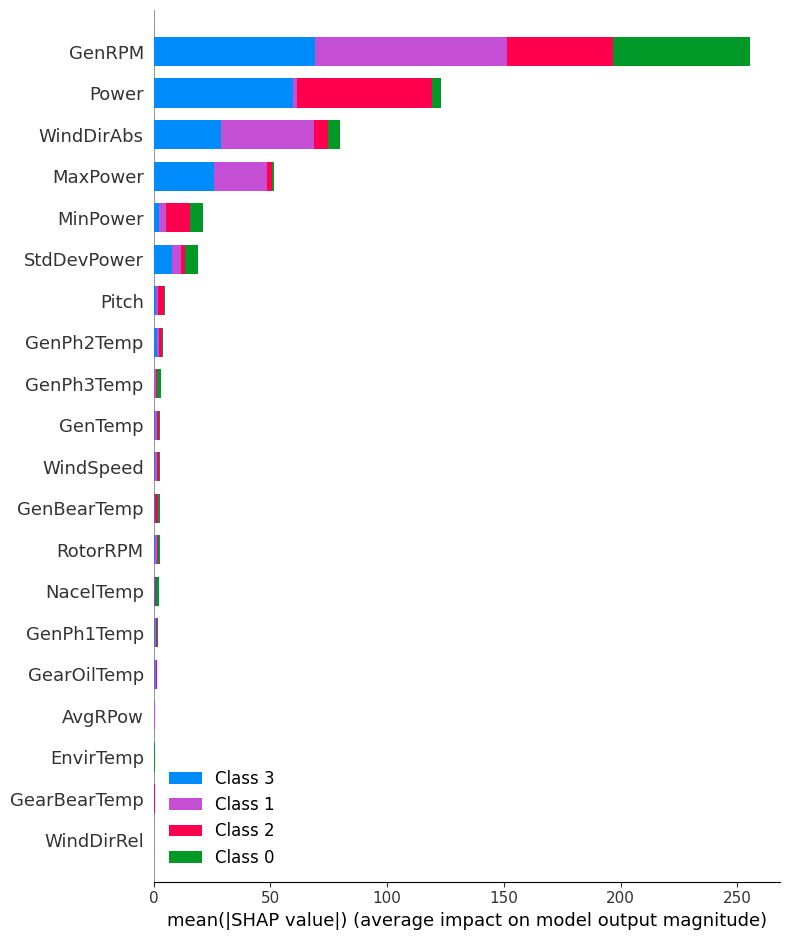

In [14]:
shap.summary_plot(shap_values, X_train)

# Подробное тестирование лучшей модели

In [15]:
def compute_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    report = classification_report(y_test, y_pred, target_names=class_names)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    fig = disp.figure_
    plt.close(fig)

    return {'accuracy': acc,
            'prf_report': report,
            'conf_matrix': fig,
            'predictions': y_pred}

In [16]:
metrics_best_model = compute_metrics(rf, X_test, y_test)
metrics_best_model['accuracy']

0.948625

In [17]:
print(metrics_best_model['prf_report'])

                                            precision    recall  f1-score   support

  early_gearbox_bearing_wear_elevated_temp       0.95      0.95      0.95      1998
early_yaw_bearing_wear_increased_yaw_error       0.95      0.94      0.95      2001
                high_wind_power_regulation       0.95      0.95      0.95      2003
            normal_operation_moderate_wind       0.94      0.95      0.95      1998

                                  accuracy                           0.95      8000
                                 macro avg       0.95      0.95      0.95      8000
                              weighted avg       0.95      0.95      0.95      8000



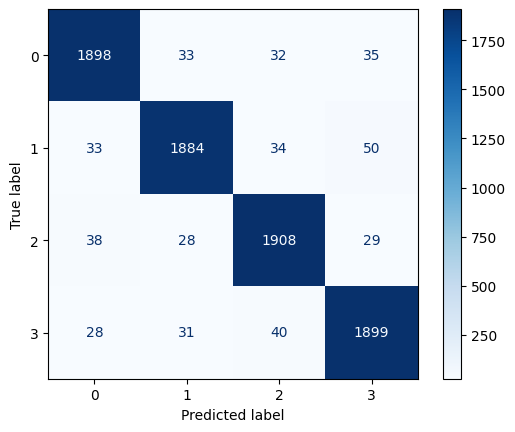

In [18]:
metrics_best_model['conf_matrix']

# Отчет

- Была рассмотрена задача "Идентификация потенциальных сбоев в работе ветряных турбин по данным вибрации и температуры" на примере турбин "Веста 52" в Гранаде, Испания
- Были построены 3 базовые модели без подбора гиперпараметров
- `RandomForestClassifier(n_estimators=100)` дал приятную метрику `f1=0.95`
- При помощи SHAP анализа были выделены следующие важные признаки: `GenRPM	(Частота вращения генератора)`, `Power	(Электрическая активная мощность)`, `WindDirAbs	(Абсолютное направление ветра)`, `MaxPower (Максимальная мощность)`, `MinPower (Минимальная мощность)`, `StdDevPower	(Стандартное отклонение мощности)`